In [68]:
import BECancerResistome
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import math
from sklearn.preprocessing import OrdinalEncoder

In [69]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Load Data

In [ ]:
annotated_plasmid_df = pd.read_csv("data/6_VEP/zscores-unambiguous-VEPannotated-processed-plasmid.csv")
annotated_control_df = pd.read_csv("data/6_VEP/zscores-unambiguous-VEPannotated-processed-control.csv")
annotated_control_vs_plasmid_EG = pd.read_csv("data/6_VEP/zscores-unambiguous-VEPannotated-processed-plasmid-vs-control-EG.csv")

In [70]:
#Most recent dataset
annotated_control_df = pd.read_csv('data/8_Cellular_Drug_Context/annotated_control_with_protabund_cnv_for_MC.csv')

/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_76793/125836893.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  annotated_control_df = pd.read_csv('data/8_Cellular_Drug_Context/annotated_control_with_protabund_cnv_for_MC.csv')


In [71]:
annotated_control_df.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,alphafold_plddt,pocket_id,min_pocket_buriedness,pocket_plddt_mean,pocket_score_combined_scaled,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore,gene_cn_total,gene_cn_category_enc,gene_cn_category_Amplification,gene_cn_category_Gain,gene_cn_category_Loss,gene_cn_category_Neutral,lnIC50,drug_target_gene_distance,is_drug_target
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN,ENST00000357387.8,Q6R327,NM_152756.5,His1109Tyr,H1109Y,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,5.531900,NaN,NaN,NaN,NaN,NaN,NaN,-0.243777,0.0,0.0,0.36936,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN,ENST00000369535.5,P01111,NM_002524.5,Leu171Phe,L171F,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6.702081,-0.239753,88.23,NaN,NaN,NaN,NaN,-0.178272,0.0,0.0,-0.61887,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN,ENST00000674063.1,P42338,NM_006219.3,Thr930Ile,T930I,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,5.786491,-0.070749,91.70,10.0,0.848224,90.132188,949.413840,-0.290119,0.0,0.0,0.05922,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,0.0,1.0
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,3.875409,NaN,NaN,6.0,0.808046,94.882812,975.087068,-0.075387,0.0,0.0,-0.74347,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,NaN,ENST00000621592.8,P01106,NM_002467.6,Asp2Asn,D2N,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,3.687539,-0.237760,55.70,NaN,NaN,NaN,NaN,-1.698486,0.0,0.0,NaN,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0


In [6]:
annotated_control_df['Gene'].value_counts()

Gene
EGFR      16395
PARP1     10400
PIK3CA     9368
MTOR       9198
AKT1       8183
BRAF       8055
NF1        8010
MAP2K2     6693
MAP2K1     5358
ERBB3      5340
ERBB2      5088
MYC        5077
PARP2      4680
RICTOR     4638
IGF1R      4608
PIK3CD     4404
ITGA3      4272
BCL2       3152
PIK3CB     2754
FGFR2      2688
SHC1       2490
RAF1       2202
GAB1       2052
PKM        1956
PGD        1752
KRAS       1678
MAPK3      1506
MAPK1      1188
PTEN       1086
GRB2        858
HRAS        708
PHLDA2      660
NRAS        588
Name: count, dtype: int64

# Gene Expression

In [7]:
gene_expression_raw_counts_df = pd.read_csv("data/8_Cellular_Context/Gene_expression/GeneExpressionExpectedCounts.csv") 
gene_expression_raw_counts_df.rename(columns={'Unnamed: 0': 'Gene'}, inplace=True)

In [8]:
gene_expression_voom_df = pd.read_csv("data/8_Cellular_Context/Gene_expression/GeneExpressionExpectedCountsVoom.csv")
gene_expression_voom_df.rename(columns={'Unnamed: 0': 'Gene'}, inplace=True)

In [9]:
gene_expression_voom_df.head()

,Gene,HT29,MHHES1,PC9,A375,H23
0,A1BG,-4.001819,2.409533,-4.204550,2.034910,1.194442
1,A1CF,-1.194464,-5.709408,-7.099853,-4.598563,-4.860841
2,A2M,-1.679891,-2.539483,-3.929928,4.816480,-0.674974
3,A2ML1,-4.738785,0.071952,-2.344965,-5.341288,-4.012844
4,A4GALT,4.003805,3.857280,2.042254,2.982142,1.774333


In [10]:
gene_expression_raw_counts_df.head()

,Gene,HT29,MHHES1,PC9,A375,H23
0,A1BG,2.0,416.5,3.22,248.70,165.75
1,A1CF,17.0,1.0,0.00,2.01,2.00
2,A2M,12.0,13.0,4.00,1713.00,45.00
3,A2ML1,1.0,82.0,13.00,1.00,4.00
4,A4GALT,642.0,1137.0,282.00,480.00,248.00


In [11]:
# Check if all our genes are in the expression dataset
set(annotated_control_df['Gene']).issubset(set(gene_expression_raw_counts_df['Gene']))

True

In [12]:
#For plasmid
set(annotated_plasmid_df['Gene']).issubset(set(gene_expression_raw_counts_df['Gene']))

True

In [13]:
# For control vs plasmid EG
set(annotated_control_vs_plasmid_EG['Gene']).issubset(set(gene_expression_raw_counts_df['Gene']))

True

In [14]:
# Check if all our genes are in the expression dataset - voom
set(annotated_control_df['Gene']).issubset(set(gene_expression_voom_df['Gene']))

True

In [15]:
#For plasmid
set(annotated_plasmid_df['Gene']).issubset(set(gene_expression_voom_df['Gene']))

True

In [16]:
# For control vs plasmid EG
set(annotated_control_vs_plasmid_EG['Gene']).issubset(set(gene_expression_voom_df['Gene']))

True

## Add gene expression to the annotated dataset

In [17]:
# Convert gene_expression_raw_counts_df to long format
gene_expression_long_df = gene_expression_raw_counts_df.melt(id_vars=['Gene'], var_name='Cell_Line', value_name='Gene_expression_expected_counts')

In [18]:
# Convert gene_expression_voom_df to long format
gene_expression_voom_long_df = gene_expression_voom_df.melt(id_vars=['Gene'], var_name='Cell_Line', value_name='Gene_expression_voom')

In [19]:
gene_expression_long_df.head()

,Gene,Cell_Line,Gene_expression_expected_counts
0,A1BG,HT29,2.0
1,A1CF,HT29,17.0
2,A2M,HT29,12.0
3,A2ML1,HT29,1.0
4,A4GALT,HT29,642.0


In [20]:
gene_expression_voom_long_df.head()

,Gene,Cell_Line,Gene_expression_voom
0,A1BG,HT29,-4.001819
1,A1CF,HT29,-1.194464
2,A2M,HT29,-1.679891
3,A2ML1,HT29,-4.738785
4,A4GALT,HT29,4.003805


In [21]:
#Merge with annotated_control_df
annotated_control_df = annotated_control_df.merge(gene_expression_long_df, on=["Gene", "Cell_Line"], how="left")

In [22]:
#For plasmid
annotated_plasmid_df = annotated_plasmid_df.merge(gene_expression_long_df, on=["Gene", "Cell_Line"], how="left")

In [23]:
# For control vs plasmid EG
annotated_control_vs_plasmid_EG = annotated_control_vs_plasmid_EG.merge(gene_expression_long_df, on=["Gene", "Cell_Line"], how="left")

In [24]:
#Merge voom data with annotated_control_df
annotated_control_df = annotated_control_df.merge(gene_expression_voom_long_df, on=["Gene", "Cell_Line"], how="left")

In [25]:
#For plasmid
annotated_plasmid_df = annotated_plasmid_df.merge(gene_expression_voom_long_df, on=["Gene", "Cell_Line"], how="left")

In [26]:
#For control vs plasmid EG
annotated_control_vs_plasmid_EG = annotated_control_vs_plasmid_EG.merge(gene_expression_voom_long_df, on=["Gene", "Cell_Line"], how="left")

In [27]:
annotated_control_df.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,RefSeq match transcript (MANE Select),Amino Acid Edits,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_expected_counts,Gene_expression_voom
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN,ENST00000357387.8,NM_152756.5,His1109Tyr,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,2813.00,5.531900
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN,ENST00000369535.5,NM_002524.5,Leu171Phe,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6331.00,6.702081
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN,ENST00000674063.1,NM_006219.3,Thr930Ile,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,3356.00,5.786491
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN,ENST00000275493.7,NM_005228.5,Leu480Leu,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,891.97,3.875409
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,NaN,ENST00000621592.8,NM_002467.6,Asp2Asn,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,783.00,3.687539


In [28]:
annotated_plasmid_df.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,RefSeq match transcript (MANE Select),Amino Acid Edits,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_expected_counts,Gene_expression_voom
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.081987,non-hit,NaN,ENST00000357387.8,NM_152756.5,His1109Tyr,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,2813.00,5.531900
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.781556,non-hit,NaN,ENST00000369535.5,NM_002524.5,Leu171Phe,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6331.00,6.702081
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,-0.275840,non-hit,NaN,ENST00000674063.1,NM_006219.3,Thr930Ile,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,3356.00,5.786491
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,0.449610,non-hit,NaN,ENST00000275493.7,NM_005228.5,Leu480Leu,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,891.97,3.875409
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.068485,non-hit,NaN,ENST00000621592.8,NM_002467.6,Asp2Asn,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,783.00,3.687539


In [29]:
annotated_control_vs_plasmid_EG.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Target Transcript ID,RefSeq match transcript (MANE Select),Amino Acid Edits,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,am_pathogenicity,EVE_SCORE,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_expected_counts,Gene_expression_voom
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,DO,-0.126512,non-hit,ENST00000357387.8,NM_152756.5,His1109Tyr,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,0.0685,NaN,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,2813.00,5.531900
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,DO,0.491844,non-hit,ENST00000369535.5,NM_002524.5,Leu171Phe,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,0.1149,NaN,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6331.00,6.702081
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,DO,0.161287,non-hit,ENST00000674063.1,NM_006219.3,Thr930Ile,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,0.7209,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,3356.00,5.786491
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,DO,-0.429684,non-hit,ENST00000275493.7,NM_005228.5,Leu480Leu,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,891.97,3.875409
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,DO,0.122982,non-hit,ENST00000621592.8,NM_002467.6,Asp2Asn,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,NaN,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,783.00,3.687539


In [32]:
#Check data type of Gene_expression_raw_counts and missing values
print(f'Gene expression raw counts data type: {annotated_control_df["Gene_expression_expected_counts"].dtype}')
print(f'Gene expression voom data type: {annotated_control_df["Gene_expression_voom"].dtype}')
print(f'Missing values in Gene expression raw counts: {annotated_control_df["Gene_expression_expected_counts"].isnull().sum()}')
print(f'Missing values in Gene expression voom: {annotated_control_df["Gene_expression_voom"].isnull().sum()}')

Gene expression raw counts data type: float64
Gene expression voom data type: float64
Missing values in Gene expression raw counts: 0
Missing values in Gene expression voom: 0


### Check correlation between raw counts and voom normalized counts

In [33]:
corr = annotated_control_df[["Gene_expression_expected_counts", "Gene_expression_voom"]].corr().iloc[0, 1]
print(f"Correlation between raw counts and voom expression: {corr:.3f}")

Correlation between raw counts and voom expression: 0.565


In [34]:
# Compute correlation matrix
meta_cols=[
    'Target Transcript ID', 'RefSeq match transcript (MANE Select)', 'Guide', 'Editor', 'Gene', 'Cell_Line','Drug', 'Amino Acid Edits', 
    'Hit_class', 'Source'
]
training_features_df = annotated_control_df.drop(columns=meta_cols, errors='ignore')
corr_matrix = training_features_df.corr()
corr_matrix

,zscore,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_expected_counts,Gene_expression_voom
zscore,1.000000,0.005580,0.009687,0.003192,0.000537,0.009252,0.017340,0.009143,-0.001380,0.019796,0.005565,-0.003373,-0.010815,-0.017684,-0.013698,-0.005542,-0.023489,-0.008520,-0.006097,-0.003878,-0.003883,0.013084,0.015616,0.008538,0.036944,0.003836,-0.000020,-0.010329,0.025774,0.030039,0.020174,0.006376,0.006258,0.011367,0.007380,-0.012911,0.004146,-0.017018,-0.010445,0.008788,0.011065,-0.004896,0.000833,0.002588,-0.001573,-0.006294,-0.005279,0.001008,-0.004738,-0.002245,0.015429,0.011072
Mutation_Category_enc,0.005580,1.000000,0.881596,0.029185,NaN,NaN,NaN,0.024930,NaN,NaN,0.499673,0.080880,NaN,NaN,0.399749,0.228337,0.038355,0.022348,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.050046,-0.371289,NaN,0.023396,0.011618,0.699761,-0.569096,0.703704,-0.009024,0.021053,0.021396,0.035252,-0.013587,0.257666,0.350031,0.076528,0.224562,NaN,-0.044145,0.271125,0.684482,-0.003126,-0.003276
IMPACT_enc,0.009687,0.881596,1.000000,0.029407,-0.025518,-0.028446,NaN,0.034540,NaN,NaN,0.494446,0.075996,-0.023172,0.006956,0.382677,0.218199,0.015932,0.014697,0.005975,NaN,NaN,0.035354,0.077140,-0.017801,0.009466,NaN,0.038288,0.007288,0.039934,-0.040155,-0.389026,-0.004843,0.021960,-0.000821,0.840489,-0.592524,0.739414,0.000197,-0.001799,0.048220,0.051944,-0.039675,0.210187,0.290299,0.062116,0.144738,0.012958,-0.039772,0.270620,0.705184,-0.003394,-0.003317
TSL,0.003192,0.029185,0.029407,1.000000,0.007227,0.001570,0.085716,0.073154,-0.000530,0.078467,0.123550,0.030043,0.158578,0.055244,0.020496,0.084410,0.104515,0.117883,0.132012,0.221394,0.299522,0.097239,0.087195,0.003332,0.248101,-0.027972,0.014106,-0.201757,0.102417,0.115156,0.047695,0.125544,0.094766,0.132202,0.041926,-0.023269,0.037025,0.011584,-0.019711,0.027593,0.021723,-0.042235,-0.013664,0.006642,-0.018329,0.024825,-0.021902,-0.280083,NaN,0.002640,-0.124303,-0.193436
SIFT_pathogenicity,0.000537,NaN,-0.025518,0.007227,1.000000,-0.428071,-0.418746,-0.523837,-0.409153,-0.437631,-0.456021,-0.516157,-0.361067,0.436314,-0.399628,-0.545863,-0.006957,-0.327134,-0.412668,-0.388512,-0.349973,-0.362482,-0.521755,-0.325622,-0.294628,-0.430232,0.448310,0.268803,-0.437184,-0.011084,-0.535454,-0.427254,-0.335860,-0.446583,-0.601584,0.090263,-0.029994,0.090615,-0.019852,0.041873,0.011411,-0.010341,0.009993,-0.017242,0.036257,0.004884,0.184099,0.040954,-0.104963,-0.220315,0.013472,-0.004644
PolyPhen_pathogenicity,0.009252,NaN,-0.028446,0.001570,-0.428071,1.000000,0.697214,0.582732,0.726036,0.683534,0.611748,0.313536,0.483070,-0.610666,0.699347,0.669297,-0.005068,0.257816,0.406567,0.533310,0.553507,0.420635,0.759944,0.561384,0.305925,0.567730,-0.659064,-0.330388,0.682364,0.069218,0.524962,0.604114,0.263534,0.458758,0.650425,0.026374,-0.032662,0.008808,-0.034430,0.037646,0.055455,-0.030133,-0.004480,-0.011546,-0.007328,-0.020013,-0.291905,0.035940,0.310079,0.137155,0.007433,-0.006578
REVEL,0.017340,NaN,NaN,0.085716,-0.418746,0.697214,1.000000,0.590339,0.717015,0.750411,0.900169,0.295004,0.621157,-0.705263,0.679153,0.645375,0.037068,0.320508,0.443130,0.586054,0.624602,0.699880,0.852233,0.860712,0.486146,0.584907,-0.722336,-0.467654,0.759671,0.095134,0.626483,0.715063,0.322869,0.570628,0.630129,0.070819,

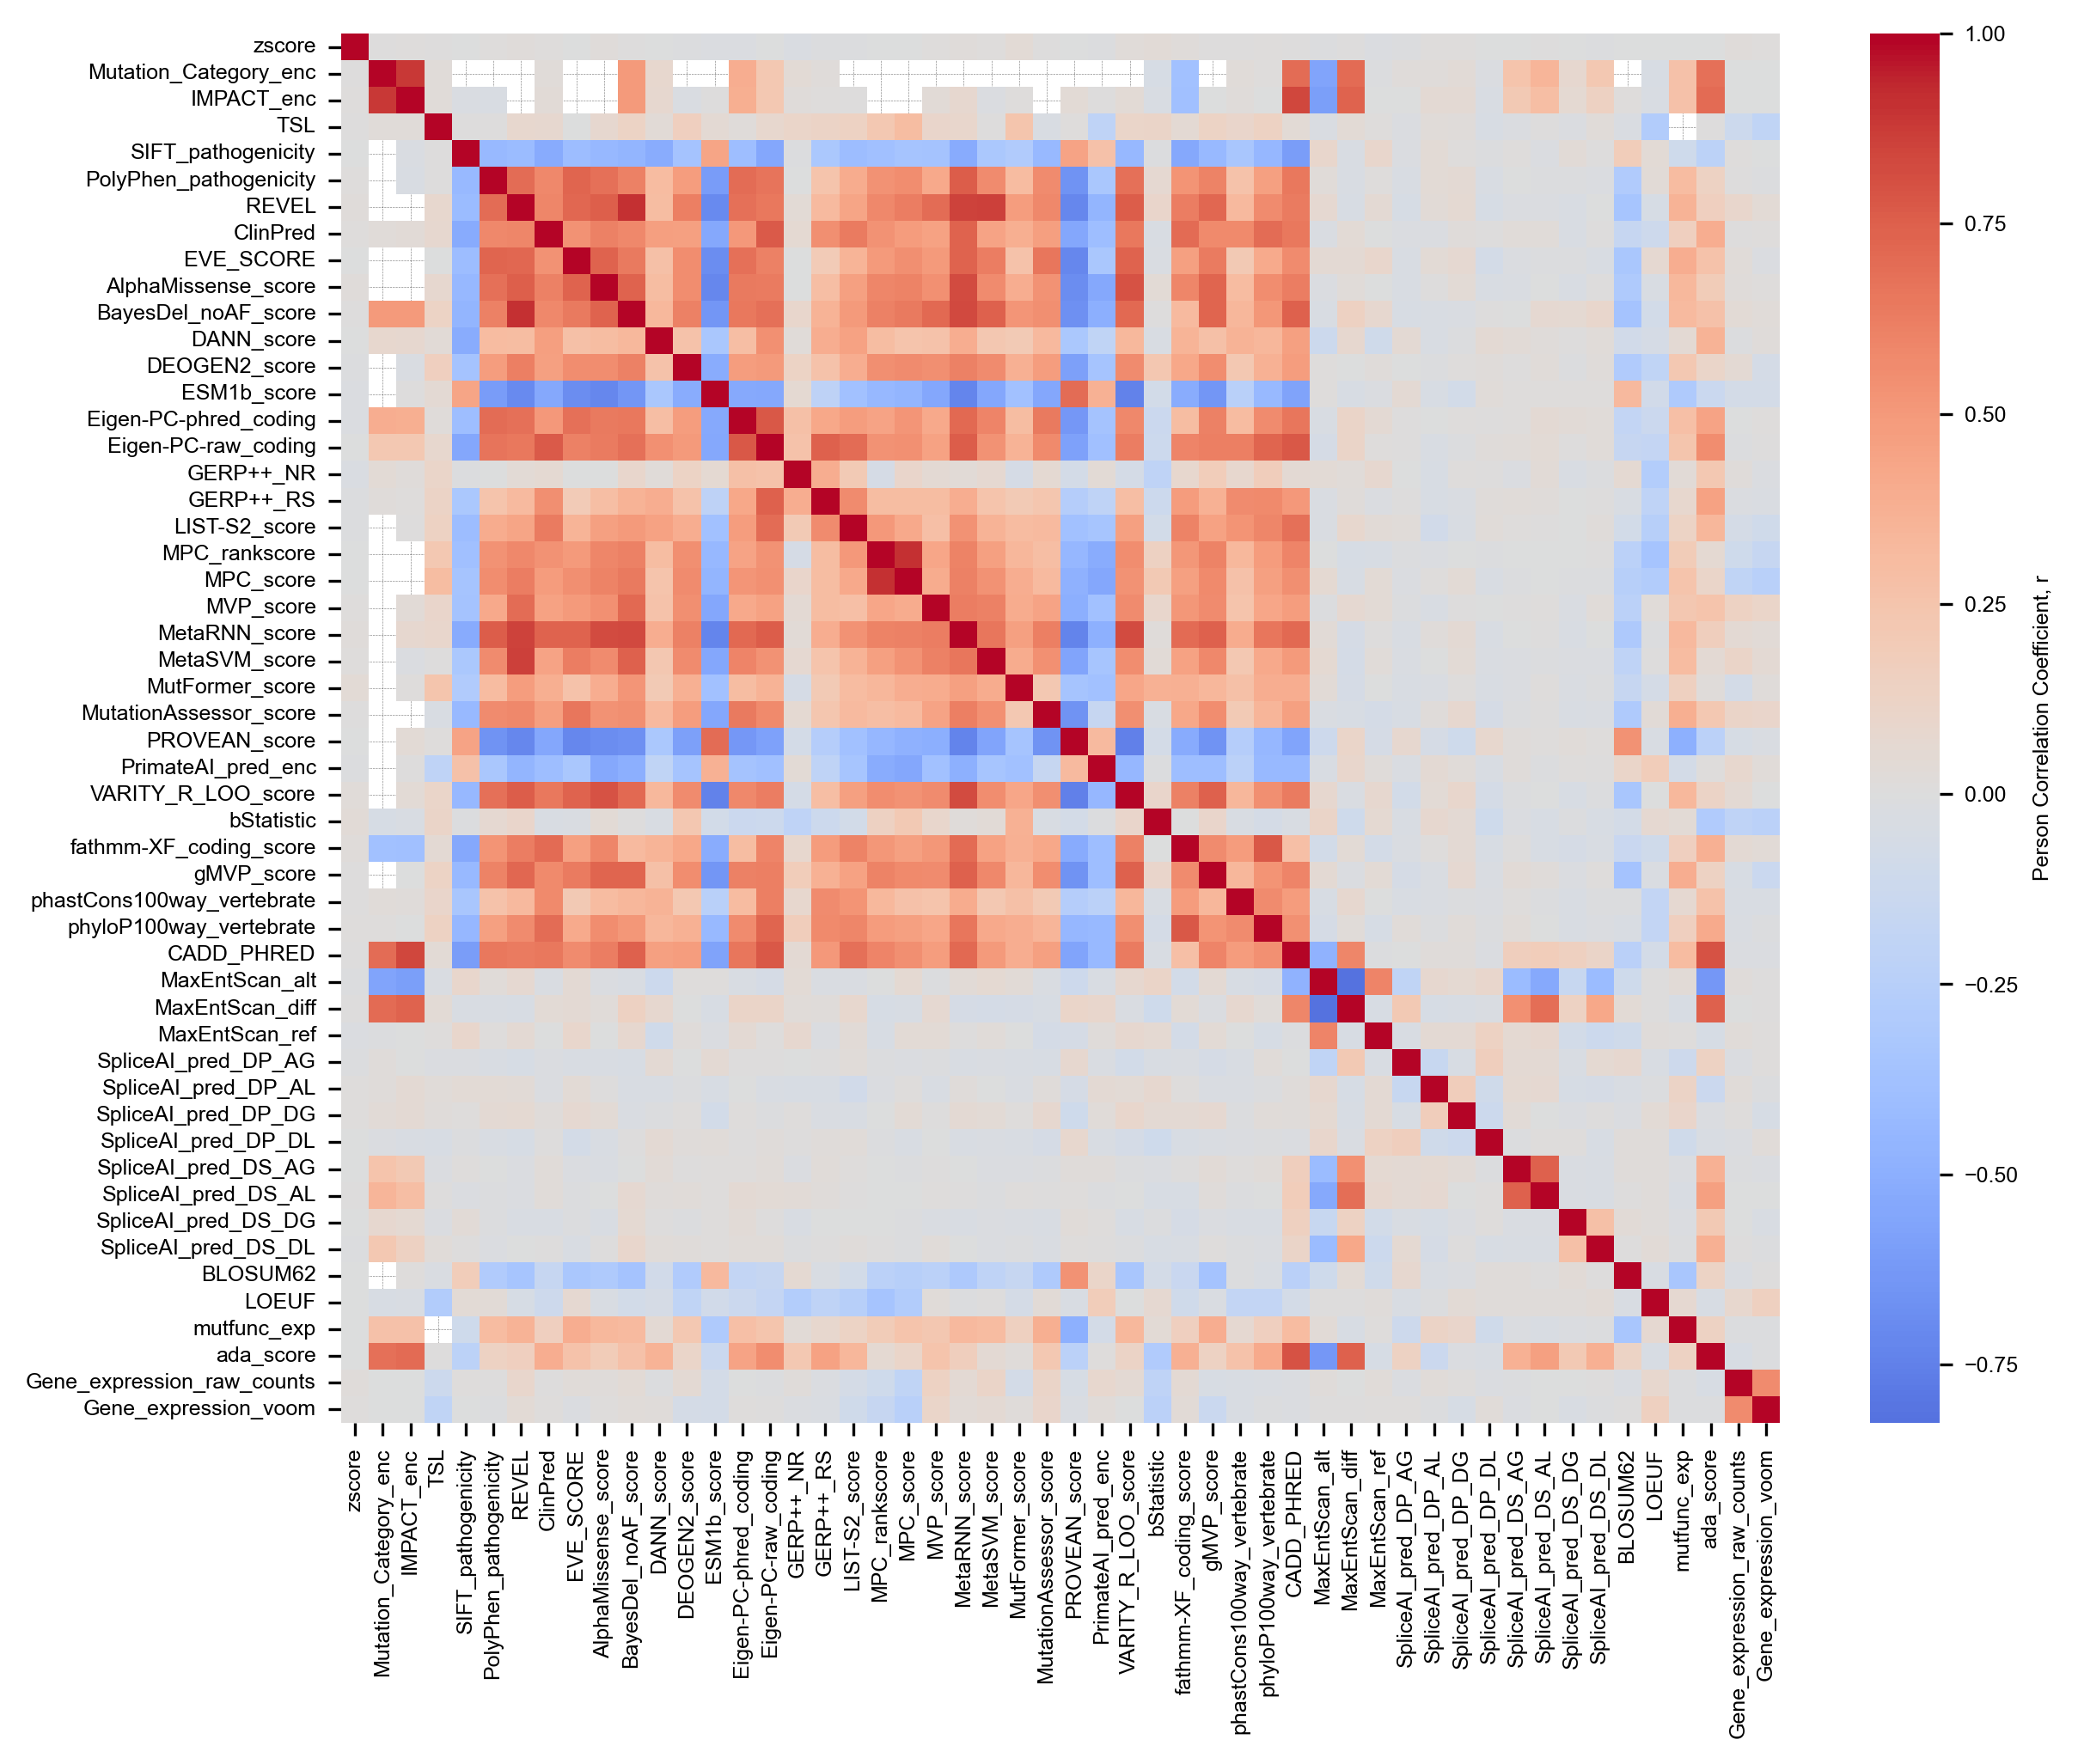

In [45]:
# Plot heatmap
plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, cbar_kws={'label': 'Person Correlation Coefficient, r'})
plt.show()

In [35]:
#Save dataframe
annotated_control_df.to_csv("data/8_Cellular_Context/zscores-unambiguous-VEPannotated-processed-control-with-gene-expression.csv", index=False)

In [36]:
#For plasmid
annotated_plasmid_df.to_csv("data/8_Cellular_Context/zscores-unambiguous-VEPannotated-processed-plasmid-with-gene-expression.csv", index=False)

In [37]:
# For control vs plasmid EG
annotated_control_vs_plasmid_EG.to_csv("data/8_Cellular_Context/zscores-unambiguous-VEPannotated-processed-plasmid-vs-control-EG-with-gene-expression.csv", index=False)

In [8]:
#I'll delete raw counts as we're only using voom from now on
annotated_control_df = pd.read_csv("data/8_Cellular_Context/zscores-unambiguous-VEPannotated-processed-control-with-gene-expression.csv")
annotated_plasmid_df = pd.read_csv("data/8_Cellular_Context/zscores-unambiguous-VEPannotated-processed-plasmid-with-gene-expression.csv")

/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_74057/290913433.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  annotated_control_df = pd.read_csv("data/8_Celular_Context/zscores-unambiguous-VEPannotated-processed-control-with-gene-expression.csv")
/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_74057/290913433.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  annotated_plasmid_df = pd.read_csv("data/8_Celular_Context/zscores-unambiguous-VEPannotated-processed-plasmid-with-gene-expression.csv")


In [11]:
annotated_control_df.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,RefSeq match transcript (MANE Select),Amino Acid Edits,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN,ENST00000357387.8,NM_152756.5,His1109Tyr,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,5.531900
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN,ENST00000369535.5,NM_002524.5,Leu171Phe,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6.702081
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN,ENST00000674063.1,NM_006219.3,Thr930Ile,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,5.786491
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN,ENST00000275493.7,NM_005228.5,Leu480Leu,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,3.875409
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,NaN,ENST00000621592.8,NM_002467.6,Asp2Asn,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,3.687539


In [13]:
annotated_plasmid_df.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,RefSeq match transcript (MANE Select),Amino Acid Edits,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.081987,non-hit,NaN,ENST00000357387.8,NM_152756.5,His1109Tyr,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,5.531900
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.781556,non-hit,NaN,ENST00000369535.5,NM_002524.5,Leu171Phe,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6.702081
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,-0.275840,non-hit,NaN,ENST00000674063.1,NM_006219.3,Thr930Ile,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,5.786491
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,0.449610,non-hit,NaN,ENST00000275493.7,NM_005228.5,Leu480Leu,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,3.875409
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.068485,non-hit,NaN,ENST00000621592.8,NM_002467.6,Asp2Asn,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,3.687539


In [12]:
annotated_control_df = annotated_control_df.drop(columns=['Gene_expression_expected_counts'])
annotated_plasmid_df = annotated_plasmid_df.drop(columns=['Gene_expression_expected_counts'])

In [14]:
#Save dataframe
annotated_control_df.to_csv("data/8_Cellular_Context/zscores-unambiguous-VEPannotated-processed-control-with-gene-expression.csv", index=False)
annotated_plasmid_df.to_csv("data/8_Cellular_Context/zscores-unambiguous-VEPannotated-processed-plasmid-with-gene-expression.csv", index=False)

# CRISPR Cas9 Essentiality

In [36]:
crispr_essentiality_df = pd.read_csv("data/8_Celular_Context/CRISPR_essentiality/crispr_depmap.csv")
crispr_essentiality_df.rename(columns={'Unnamed: 0': 'Gene'}, inplace=True)

In [41]:
crispr_essentiality_df.head()


,Gene,H23,HT29,MHHES1,A375
0,A1BG,-0.051350,0.041170,-0.032326,-0.143012
1,A1CF,-0.083833,0.013346,0.010977,0.010408
2,A2M,0.037981,-0.035249,0.019658,0.084055
3,A2ML1,-0.050949,0.065066,0.163994,0.111621
4,A3GALT2,0.070183,0.053097,-0.204127,-0.043891


In [37]:
# Check if all our genes are in the CRISPR essentiality dataset
set(annotated_control_df['Gene']).issubset(set(crispr_essentiality_df['Gene']))

True

### Add CRISPR Cas9 Essentiality to the dataset

In [39]:
# Convert crispr_essentiality_df to long format
crispr_long_df = crispr_essentiality_df.melt(id_vars=['Gene'], var_name='Cell_Line', value_name='CRISPR_essentiality_score')

In [40]:
crispr_long_df.head()

,Gene,Cell_Line,CRISPR_essentiality_score
0,A1BG,H23,-0.051350
1,A1CF,H23,-0.083833
2,A2M,H23,0.037981
3,A2ML1,H23,-0.050949
4,A3GALT2,H23,0.070183


In [42]:
#Merge with annotated_control_df
annotated_control_df = annotated_control_df.merge(crispr_long_df, on=["Gene", "Cell_Line"], how="left")

In [43]:
annotated_control_df.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_expected_counts,Gene_expression_voom,wild_type,uniprot_position,mutated_type,foldx_ddg,alphafold_plddt,pocket_id,min_pocket_buriedness,pocket_plddt_mean,pocket_score_combined_scaled,CRISPR_essentiality_score
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN,ENST00000357387.8,Q6R327,NM_152756.5,His1109Tyr,H1109Y,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,2813.00,5.531900,H,1109.0,Y,NaN,NaN,NaN,NaN,NaN,NaN,-0.243777
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN,ENST00000369535.5,P01111,NM_002524.5,Leu171Phe,L171F,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6331.00,6.702081,L,171.0,F,-0.239753,88.23,NaN,NaN,NaN,NaN,-0.178272
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN,ENST00000674063.1,P42338,NM_006219.3,Thr930Ile,T930I,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,3356.00,5.786491,T,930.0,I,-0.070749,91.70,10.0,0.848224,90.132188,949.413840,-0.290119
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,891.97,3.875409,L,480.0,L,NaN,NaN,6.0,0.808046,94.882812,975.087068,-0.075387
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,NaN,ENST00000621592.8,P01106,NM_002467.6,Asp2Asn,D2N,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,783.00,3.687539,D,2.0,N,-0.237760,55.70,NaN,NaN,NaN,NaN,-1.698486


In [44]:
#Merge with annotated_control_confident_df
annotated_control_confident_df = annotated_control_confident_df.merge(crispr_long_df, on=["Gene", "Cell_Line"], how="left")

In [45]:
annotated_control_confident_df.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,pocket_id,min_pocket_buriedness,CRISPR_essentiality_score
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN,ENST00000357387.8,Q6R327,NM_152756.5,His1109Tyr,H1109Y,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,5.531900,NaN,NaN,NaN,-0.243777
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN,ENST00000369535.5,P01111,NM_002524.5,Leu171Phe,L171F,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6.702081,-0.239753,NaN,NaN,-0.178272
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN,ENST00000674063.1,P42338,NM_006219.3,Thr930Ile,T930I,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,5.786491,-0.070749,10.0,0.848224,-0.290119
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,3.875409,NaN,6.0,0.808046,-0.075387
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,NaN,ENST00000621592.8,P01106,NM_002467.6,Asp2Asn,D2N,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,3.687539,NaN,NaN,NaN,-1.698486


In [46]:
#Check missing values
print(f'Missing values in CRISPR essentiality score: {annotated_control_confident_df["CRISPR_essentiality_score"].isnull().sum()}')

Missing values in CRISPR essentiality score: 15662


In [47]:
annotated_control_confident_df['Cell_Line'].value_counts()

Cell_Line
HT29      65505
A375      42012
H23       15662
PC9       15662
MHHES1     8244
Name: count, dtype: int64

In [48]:
annotated_control_df.to_csv('data/8_Cellular_Context/zscores-unambiguous-VEPannotated-processed-gene-expression-foldx-pocket-crispr-control.csv', index=False)

In [49]:
annotated_control_confident_df.to_csv('data/8_Cellular_Context/zscores-unambiguous-VEPannotated-processed-gene-expression-foldx-pocket-confident-crispr-control.csv', index=False)

# Protein Abundance

In [11]:
proteomics = pd.read_csv("data/8_Cellular_Drug_Context/Proteomics/proteomics_selected_genes_MC.csv")

In [16]:
proteomics.head()

,Gene_Symbol,sample,value
0,EGFR,HT29,0.33269
1,KRAS,HT29,-0.03654
2,BRAF,HT29,-0.19615
3,MAP2K1,HT29,0.80351
4,MAP2K2,HT29,0.14338


In [17]:
proteomics['sample'].unique()

array(['HT29', 'A375', 'H23'], dtype=object)

In [15]:
# Map Sample ID to the correspondent Cell Line
proteomics['sample'] = proteomics['sample'].replace({'SIDM00136': 'HT29', 'SIDM00795': 'A375', 'SIDM00138': 'H23'})

In [19]:
proteomics.head()

,Gene_Symbol,sample,value
0,EGFR,HT29,0.33269
1,KRAS,HT29,-0.03654
2,BRAF,HT29,-0.19615
3,MAP2K1,HT29,0.80351
4,MAP2K2,HT29,0.14338


In [38]:
annotated_control_df.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_expected_counts,Gene_expression_voom,wild_type,uniprot_position,mutated_type,foldx_ddg,alphafold_plddt,pocket_id,min_pocket_buriedness,pocket_plddt_mean,pocket_score_combined_scaled,CRISPR_essentiality_score,is_in_interface,interface_count
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN,ENST00000357387.8,Q6R327,NM_152756.5,His1109Tyr,H1109Y,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,2813.00,5.531900,H,1109.0,Y,NaN,NaN,NaN,NaN,NaN,NaN,-0.243777,0.0,0.0
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN,ENST00000369535.5,P01111,NM_002524.5,Leu171Phe,L171F,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6331.00,6.702081,L,171.0,F,-0.239753,88.23,NaN,NaN,NaN,NaN,-0.178272,0.0,0.0
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN,ENST00000674063.1,P42338,NM_006219.3,Thr930Ile,T930I,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,3356.00,5.786491,T,930.0,I,-0.070749,91.70,10.0,0.848224,90.132188,949.413840,-0.290119,0.0,0.0
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,891.97,3.875409,L,480.0,L,NaN,NaN,6.0,0.808046,94.882812,975.087068,-0.075387,0.0,0.0
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,NaN,ENST00000621592.8,P01106,NM_002467.6,Asp2Asn,D2N,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,783.00,3.687539,D,2.0,N,-0.237760,55.70,NaN,NaN,NaN,NaN,-1.698486,0.0,0.0


In [66]:
# Merge to the annotated dataset
annotated_control_proteomics_df = annotated_control_confident_df.merge(proteomics, left_on=['Gene', 'Cell_Line'], right_on=['Gene_Symbol', 'sample'], how='left')
annotated_control_proteomics_df.rename(columns={'value': 'protein_abundance_zscore'}, inplace=True)

In [37]:
#For MC annotation
merged = annotated_control_df.merge(proteomics, left_on=['Gene', 'Cell_Line'], right_on=['Gene_Symbol', 'sample'], how='left')
merged['protein_abundance_zscore'] = (merged['protein_abundance_zscore'].fillna(merged['value']))
merged = merged.drop(columns=['Gene_Symbol', 'sample', 'value'])

In [38]:
merged.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,alphafold_plddt,pocket_id,min_pocket_buriedness,pocket_plddt_mean,pocket_score_combined_scaled,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore,gene_cn_total,gene_cn_category_enc,gene_cn_category_Amplification,gene_cn_category_Gain,gene_cn_category_Loss,gene_cn_category_Neutral,lnIC50,drug_target_gene_distance,is_drug_target
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN,ENST00000357387.8,Q6R327,NM_152756.5,His1109Tyr,H1109Y,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,5.531900,NaN,NaN,NaN,NaN,NaN,NaN,-0.243777,0.0,0.0,0.36936,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN,ENST00000369535.5,P01111,NM_002524.5,Leu171Phe,L171F,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6.702081,-0.239753,88.23,NaN,NaN,NaN,NaN,-0.178272,0.0,0.0,-0.61887,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN,ENST00000674063.1,P42338,NM_006219.3,Thr930Ile,T930I,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,5.786491,-0.070749,91.70,10.0,0.848224,90.132188,949.413840,-0.290119,0.0,0.0,0.05922,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,0.0,1.0
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,3.875409,NaN,NaN,6.0,0.808046,94.882812,975.087068,-0.075387,0.0,0.0,-0.74347,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,NaN,ENST00000621592.8,P01106,NM_002467.6,Asp2Asn,D2N,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,3.687539,-0.237760,55.70,NaN,NaN,NaN,NaN,-1.698486,0.0,0.0,NaN,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0


In [67]:
#drop Gene_Symbol and sample columns
annotated_control_proteomics_df = annotated_control_proteomics_df.drop(columns=['Gene_Symbol', 'sample'])

In [68]:
annotated_control_proteomics_df.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,pocket_id,min_pocket_buriedness,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN,ENST00000357387.8,Q6R327,NM_152756.5,His1109Tyr,H1109Y,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,5.531900,NaN,NaN,NaN,-0.243777,0.0,0.0,0.36936
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN,ENST00000369535.5,P01111,NM_002524.5,Leu171Phe,L171F,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6.702081,-0.239753,NaN,NaN,-0.178272,0.0,0.0,-0.61887
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN,ENST00000674063.1,P42338,NM_006219.3,Thr930Ile,T930I,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,5.786491,-0.070749,10.0,0.848224,-0.290119,0.0,0.0,0.05922
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,3.875409,NaN,6.0,0.808046,-0.075387,0.0,0.0,-0.74347
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,NaN,ENST00000621592.8,P01106,NM_002467.6,Asp2Asn,D2N,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,3.687539,NaN,NaN,NaN,-1.698486,0.0,0.0,NaN


In [70]:
len(annotated_control_proteomics_df)

147085

In [69]:
annotated_control_proteomics_df.to_csv('data/8_Cellular_Drug_Context/zscores-unambiguous-VEPannotated-processed-gene-expression-protvar-confident-crispr-proteomics-control.csv', index=False)

# Gene Copy Number Level 

In [27]:
cnv = pd.read_csv('data/8_Cellular_Drug_Context/Gene_expression_cnv/cnv_selected_genes_MC.csv')

In [28]:
cnv.head()

,symbol,sample,cn_category,cn_total
0,EGFR,SIDM00136,Gain,4.0
1,KRAS,SIDM00136,Gain,4.0
2,BRAF,SIDM00136,Gain,4.0
3,MAP2K1,SIDM00136,Gain,4.0
4,MAP2K2,SIDM00136,Loss,2.0


In [29]:
cnv['symbol'].unique()

array(['EGFR', 'KRAS', 'BRAF', 'MAP2K1', 'MAP2K2', 'PIK3CA', 'AKT1',
       'MYC', 'BCL2', 'PARP1', 'PARP2'], dtype=object)

In [30]:
cnv['sample'].unique()

array(['SIDM00136', 'SIDM00795', 'SIDM00138', 'SIDM00386'], dtype=object)

In [32]:
# Map Sample ID to the correspondent Cell Line
cnv['sample'] = cnv['sample'].replace({'SIDM00136': 'HT29', 'SIDM00795': 'A375', 'SIDM00138': 'H23', 'SIDM00386': 'MHHES1'})

In [33]:
cnv.head()

,symbol,sample,cn_category,cn_total
0,EGFR,HT29,Gain,4.0
1,KRAS,HT29,Gain,4.0
2,BRAF,HT29,Gain,4.0
3,MAP2K1,HT29,Gain,4.0
4,MAP2K2,HT29,Loss,2.0


In [21]:
# Merge to the annotated dataset
annotated_control_cnv_df = annotated_control_confident_df.merge(cnv, left_on=['Gene', 'Cell_Line'], right_on=['symbol', 'sample'], how='left')
annotated_control_cnv_df.rename(columns={'cn_category': 'gene_cn_category', 'cn_total':'gene_cn_total'}, inplace=True)

In [39]:
#MC annotation
merged_cnv = merged.merge(cnv, left_on=['Gene', 'Cell_Line'], right_on=['symbol', 'sample'], how='left')
merged_cnv.rename(columns={'cn_category': 'gene_cn_category_mc', 'cn_total':'gene_cn_total_mc'}, inplace=True)

In [40]:
merged_cnv.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,alphafold_plddt,pocket_id,min_pocket_buriedness,pocket_plddt_mean,pocket_score_combined_scaled,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore,gene_cn_total,gene_cn_category_enc,gene_cn_category_Amplification,gene_cn_category_Gain,gene_cn_category_Loss,gene_cn_category_Neutral,lnIC50,drug_target_gene_distance,is_drug_target,symbol,sample,gene_cn_category_mc,gene_cn_total_mc
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN,ENST00000357387.8,Q6R327,NM_152756.5,His1109Tyr,H1109Y,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,5.531900,NaN,NaN,NaN,NaN,NaN,NaN,-0.243777,0.0,0.0,0.36936,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0,NaN,NaN,NaN,NaN
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN,ENST00000369535.5,P01111,NM_002524.5,Leu171Phe,L171F,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6.702081,-0.239753,88.23,NaN,NaN,NaN,NaN,-0.178272,0.0,0.0,-0.61887,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0,NaN,NaN,NaN,NaN
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN,ENST00000674063.1,P42338,NM_006219.3,Thr930Ile,T930I,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,5.786491,-0.070749,91.70,10.0,0.848224,90.132188,949.413840,-0.290119,0.0,0.0,0.05922,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,0.0,1.0,NaN,NaN,NaN,NaN
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,3.875409,NaN,NaN,6.0,0.808046,94.882812,975.087068,-0.075387,0.0,0.0,-0.74347,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0,EGFR,A375,Neutral,3.0
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,NaN,ENST00000621592.8,P01106,NM_002467.6,Asp2Asn,D2N,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,3.687539,-0.237760,55.70,NaN,NaN,NaN,NaN,-1.698486,0.0,0.0,NaN,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0,MYC,A375,Neutral,3.0


In [ ]:
#drop symbol and sample columns
annotated_control_cnv_df = annotated_control_cnv_df.drop(columns=['symbol', 'sample'])

In [42]:
# Ordinal encoding of gene_cn_category
cn_ordinal_map = {
    'Deletion':0,
    'Loss': 1,
    'Neutral':2,
    'Gain':3,
    'Amplification':4
}

merged_cnv['gene_cn_category_enc_mc'] = merged_cnv['gene_cn_category_mc'].map(cn_ordinal_map)

In [44]:
#Dummy encoding of gene_cn_category
cn_dummies = pd.get_dummies(merged_cnv['gene_cn_category_mc'], prefix='gene_cn_category_mc', dtype=float)

In [45]:
cn_dummies.head()

,gene_cn_category_mc_Amplification,gene_cn_category_mc_Gain,gene_cn_category_mc_Loss,gene_cn_category_mc_Neutral
0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,1.0


In [46]:
len(cn_dummies)

147085

In [48]:
merged_cnv = pd.concat([merged_cnv, cn_dummies],axis=1)

In [60]:
merged_cnv.head(10)

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,alphafold_plddt,pocket_id,min_pocket_buriedness,pocket_plddt_mean,pocket_score_combined_scaled,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore,gene_cn_total,gene_cn_category_enc,gene_cn_category_Amplification,gene_cn_category_Gain,gene_cn_category_Loss,gene_cn_category_Neutral,lnIC50,drug_target_gene_distance,is_drug_target
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN,ENST00000357387.8,Q6R327,NM_152756.5,His1109Tyr,H1109Y,3.0,2.0,1.0,1.00,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,5.531900,NaN,NaN,NaN,NaN,NaN,NaN,-0.243777,0.0,0.0,0.36936,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN,ENST00000369535.5,P01111,NM_002524.5,Leu171Phe,L171F,3.0,2.0,1.0,0.10,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6.702081,-0.239753,88.23,NaN,NaN,NaN,NaN,-0.178272,0.0,0.0,-0.61887,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN,ENST00000674063.1,P42338,NM_006219.3,Thr930Ile,T930I,3.0,2.0,NaN,0.00,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,5.786491,-0.070749,91.70,10.0,0.848224,90.132188,949.413840,-0.290119,0.0,0.0,0.05922,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,0.0,1.0
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,3.875409,NaN,NaN,6.0,0.808046,94.882812,975.087068,-0.075387,0.0,0.0,-0.74347,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,NaN,ENST00000621592.8,P01106,NM_002467.6,Asp2Asn,D2N,3.0,2.0,1.0,0.00,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,3.687539,-0.237760,55.70,NaN,NaN,NaN,NaN,-1.698486,0.0,0.0,NaN,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0
5,AAAAAATCCTGTCACTTGTG,CBE,PIK3CB,A375,PIC,-0.375589,non-hit,NaN,ENST00000674063.1,P42338,NM_006219.3,Ile160Ile,I160I,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [54]:
#MC annotation
merged_cnv['gene_cn_total'] = (merged_cnv['gene_cn_total'].fillna(merged_cnv['gene_cn_total_mc']))
merged_cnv['gene_cn_category_enc'] = (merged_cnv['gene_cn_category_enc'].fillna(merged_cnv['gene_cn_category_enc_mc']))

In [56]:
#MC annotation
orig_cols = [
    'gene_cn_category_Amplification',
    'gene_cn_category_Gain',
    'gene_cn_category_Loss',
    'gene_cn_category_Neutral'
]

mc_cols = [
    'gene_cn_category_mc_Amplification',
    'gene_cn_category_mc_Gain',
    'gene_cn_category_mc_Loss',
    'gene_cn_category_mc_Neutral'
]

for i in range(len(orig_cols)):
    mask = merged_cnv[mc_cols[i]] == 1
    
    # zero out original dummy columns for those rows
    merged_cnv.loc[mask, orig_cols] = 0
    
    # set correct category
    merged_cnv.loc[mask, orig_cols[i]] = 1

In [61]:
merged_cnv[merged_cnv['Cell_Line']=='H23'].head(10)

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,alphafold_plddt,pocket_id,min_pocket_buriedness,pocket_plddt_mean,pocket_score_combined_scaled,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore,gene_cn_total,gene_cn_category_enc,gene_cn_category_Amplification,gene_cn_category_Gain,gene_cn_category_Loss,gene_cn_category_Neutral,lnIC50,drug_target_gene_distance,is_drug_target
84024,AAAAAACTGTTTGGGACCTC,CBE,EGFR,H23,ADAG,-0.493390,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.00,0.0,0.0,0.00,NaN,0.475,-0.01879,NaN,6.824679,NaN,NaN,6.0,0.808046,94.882812,975.087068,0.100856,0.0,0.0,0.09443,3.0,2.0,0.0,0.0,0.0,1.0,NaN,NaN,0.0
84025,AAAAAATCCAGCGTCTAAGC,CBE,MYC,H23,ADAG,-0.373472,non-hit,NaN,ENST00000621592.8,P01106,NM_002467.6,Asp2Asn,D2N,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.00,0.0,0.0,0.00,1.0,0.128,NaN,NaN,7.207870,-0.237760,55.70,NaN,NaN,NaN,NaN,-2.114067,0.0,0.0,1.89295,2.0,1.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0
84026,AAAAACAATTGGGAAGATCG,CBE,PARP2,H23,ADAG,0.914713,non-hit,NaN,ENST00000429687.8,Q9UGN5,NM_001042618.2,Asn173Asn,N173N,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.333,NaN,NaN,NaN,-46.0,-21.0,-22.0,30.0,0.01,0.0,0.0,0.00,NaN,0.998,NaN,NaN,5.939250,NaN,NaN,NaN,NaN,NaN,NaN,-0.105556,NaN,NaN,0.39347,3.0,2.0,0.0,0.0,0.0,1.0,NaN,NaN,0.0
84027,AAAAACTGCACCTCCATCAG,CBE,EGFR,H23,ADAG,-0.677259,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Asn361Asn,N361N,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.656,NaN,NaN,NaN,15.0,-43.0,-29.0,50.0,0.00,0.0,0.0,0.05,NaN,0.475,0.00000,NaN,6.824679,NaN,NaN,8.0,0.761069,81.607353,932.447796,0.100856,0.0,0.0,0.09443,3.0,2.0,0.0,0.0,0.0,1.0,NaN,NaN,0.0
84028,AAAAACTGTTTGGGACCTCC,CBE,EGFR,H23,ADAG,0.418113,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.00,0.0,0.0,0.00,NaN,0.475,-0.01879,NaN,6.824679,NaN,NaN,6.0,0.808046,94.882812,975.087068,0.100856,0.0,0.0,0.09443,3.0,2.0,0.0,0.0,0.0,1.0,NaN,NaN,0.0
84029,AAAAAGCAAGGGCCAGGTCA,CBE,PARP1,H23,ADAG,-0.532842,non-hit,NaN,ENST00000366794.10,P09874,NM_001618.4,Ser507Ser,S507S,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.454,NaN,NaN,8.614817,NaN,NaN,NaN,NaN,NaN,NaN,-0.315361,0.0,0.0,-0.06454,2.0,1.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0
84030,A

In [193]:
#drop gene_cn_category column
annotated_control_cnv_df = annotated_control_cnv_df.drop(columns=['gene_cn_category'])

In [59]:
#MC annotation
#drop mc_cols + symbol + sample + gene_cn_category_mc + gene_cn_total_mc + gene_cn_category_enc_mc
merged_cnv = merged_cnv.drop(columns=mc_cols + ['symbol', 'sample', 'gene_cn_category_mc', 'gene_cn_total_mc', 'gene_cn_category_enc_mc']) 

In [67]:
merged_cnv.to_csv('data/8_Cellular_Drug_Context/annotated_control_with_protabund_cnv_for_MC.csv', index=False)

# Drug Response

In [72]:
drug_response =  pd.read_csv('data/8_Cellular_Drug_Context/Drug_context/drug_response_lnIC50_MC.csv')

In [90]:
drug_response

,drug_id,HT29,A375,H23,MHHES1,Drug
0,185;Linsitinib;GDSC1,-0.871505,0.724616,3.399903,0.617723,LIN
1,1527;Pictilisib;GDSC1,0.719263,0.311144,1.530219,0.647292,PIC
2,1564;SCH772984;GDSC2,-1.530300,-0.905239,4.151005,4.325337,SCH
3,1373;Dabrafenib;GDSC2,0.161929,-3.457639,5.284136,5.781174,Dabrafenib
4,1114;Cetuximab;GDSC1,6.473371,5.731867,5.660931,6.247006,Cetuximab
5,1372;Trametinib;GDSC2,-4.911456,-4.870635,0.355247,2.780333,TRAM
6,1010;Gefitinib;GDSC2,4.980915,4.284541,3.376735,4.074771,GEFIT
7,1919;Osimertinib;GDSC2,2.306869,2.206392,2.950318,2.331854,OSIM
8,1177;Niraparib;GDSC2,5.968197,3.080186,4.058208,0.968773,NIRAP
9,1017;Olaparib;GDSC2,5.926520,3.740910,3.310407,1.405901,OLAP


In [76]:
drug_response['Drug'] = drug_response['drug_id'].str.split(';').str[1]
drug_response['Drug'] = drug_response['Drug'].replace({'Linsitinib':'LIN', 'Pictilisib':'PIC', 'SCH772984':'SCH',
                                                       'Trametinib':'TRAM', 'Gefitinib':'GEFIT', 'Osimertinib': 'OSIM',
                                                        'Niraparib': 'NIRAP', 'Olaparib': 'OLAP'})

In [77]:
drug_response['Drug'].unique()

array(['LIN', 'PIC', 'SCH', 'Dabrafenib', 'Cetuximab', 'TRAM', 'GEFIT',
       'OSIM', 'NIRAP', 'OLAP'], dtype=object)

In [78]:
#rename columns
drug_response.rename(columns={'SIDM00136': 'HT29', 'SIDM00795': 'A375', 'SIDM00138': 'H23', 'SIDM00386': 'MHHES1'}, inplace=True)

In [92]:
#convert to long format to be able to merge to the annotated dataset
drug_response_long = drug_response.melt(
    id_vars=['Drug'],          # LIN / PIC / SCH
    value_vars=['HT29', 'A375', 'H23', 'MHHES1'],  # Cell lines
    var_name='Cell_Line',
    value_name='lnIC50'
)

In [93]:
drug_response_long

,Drug,Cell_Line,lnIC50
0,LIN,HT29,-0.871505
1,PIC,HT29,0.719263
2,SCH,HT29,-1.530300
3,Dabrafenib,HT29,0.161929
4,Cetuximab,HT29,6.473371
5,TRAM,HT29,-4.911456
6,GEFIT,HT29,4.980915
7,OSIM,HT29,2.306869
8,NIRAP,HT29,5.968197
9,OLAP,HT29,5.926520


In [96]:
annotated_control_df.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,alphafold_plddt,pocket_id,min_pocket_buriedness,pocket_plddt_mean,pocket_score_combined_scaled,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore,gene_cn_total,gene_cn_category_enc,gene_cn_category_Amplification,gene_cn_category_Gain,gene_cn_category_Loss,gene_cn_category_Neutral,lnIC50,drug_target_gene_distance,is_drug_target
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN,ENST00000357387.8,Q6R327,NM_152756.5,His1109Tyr,H1109Y,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,5.531900,NaN,NaN,NaN,NaN,NaN,NaN,-0.243777,0.0,0.0,0.36936,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN,ENST00000369535.5,P01111,NM_002524.5,Leu171Phe,L171F,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6.702081,-0.239753,88.23,NaN,NaN,NaN,NaN,-0.178272,0.0,0.0,-0.61887,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN,ENST00000674063.1,P42338,NM_006219.3,Thr930Ile,T930I,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,5.786491,-0.070749,91.70,10.0,0.848224,90.132188,949.413840,-0.290119,0.0,0.0,0.05922,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,0.0,1.0
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,3.875409,NaN,NaN,6.0,0.808046,94.882812,975.087068,-0.075387,0.0,0.0,-0.74347,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,NaN,ENST00000621592.8,P01106,NM_002467.6,Asp2Asn,D2N,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,3.687539,-0.237760,55.70,NaN,NaN,NaN,NaN,-1.698486,0.0,0.0,NaN,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0


In [95]:
# merge to the annotated dataset
annotated_control_drug_response_df = annotated_control_df.merge(
    drug_response_long,
    left_on=['Drug', 'Cell_Line'],
    right_on=['Drug', 'Cell_Line'],
    how='left'
)

In [97]:
#MC annotation
annotated_control_drug_response_df = annotated_control_df.merge(
    drug_response_long,
    left_on=['Drug', 'Cell_Line'],
    right_on=['Drug', 'Cell_Line'],
    how='left',
    suffixes=('', '_mc')
)

In [102]:
annotated_control_drug_response_df.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,alphafold_plddt,pocket_id,min_pocket_buriedness,pocket_plddt_mean,pocket_score_combined_scaled,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore,gene_cn_total,gene_cn_category_enc,gene_cn_category_Amplification,gene_cn_category_Gain,gene_cn_category_Loss,gene_cn_category_Neutral,lnIC50,drug_target_gene_distance,is_drug_target,lnIC50_mc
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN,ENST00000357387.8,Q6R327,NM_152756.5,His1109Tyr,H1109Y,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,5.531900,NaN,NaN,NaN,NaN,NaN,NaN,-0.243777,0.0,0.0,0.36936,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0,0.311144
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN,ENST00000369535.5,P01111,NM_002524.5,Leu171Phe,L171F,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6.702081,-0.239753,88.23,NaN,NaN,NaN,NaN,-0.178272,0.0,0.0,-0.61887,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0,0.311144
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN,ENST00000674063.1,P42338,NM_006219.3,Thr930Ile,T930I,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,5.786491,-0.070749,91.70,10.0,0.848224,90.132188,949.413840,-0.290119,0.0,0.0,0.05922,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,0.0,1.0,0.311144
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,3.875409,NaN,NaN,6.0,0.808046,94.882812,975.087068,-0.075387,0.0,0.0,-0.74347,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0,0.311144
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,NaN,ENST00000621592.8,P01106,NM_002467.6,Asp2Asn,D2N,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,3.687539,-0.237760,55.70,NaN,NaN,NaN,NaN,-1.698486,0.0,0.0,NaN,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0,0.311144


In [101]:
annotated_control_drug_response_df[annotated_control_drug_response_df['Cell_Line']=='MHHES1'].head(10)

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,alphafold_plddt,pocket_id,min_pocket_buriedness,pocket_plddt_mean,pocket_score_combined_scaled,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore,gene_cn_total,gene_cn_category_enc,gene_cn_category_Amplification,gene_cn_category_Gain,gene_cn_category_Loss,gene_cn_category_Neutral,lnIC50,drug_target_gene_distance,is_drug_target,lnIC50_mc
138841,AAAACCGTAAAGGAAATCAC,ABE,EGFR,MHHES1,NIRAP,0.403119,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Thr397Ala,T397A,3.0,2.0,1.0,0.00,0.775,0.426,0.973457,0.309409,0.2643,0.060998,0.997374,0.920335,-10.138,5.373738,0.522861,5.95,5.95,0.830817,0.61441,0.710765,0.877131,0.946734,-0.5267,0.316769,2.980,-3.90,1.0,0.502228,954.0,0.698343,0.866349,1.000,7.022,25.700,NaN,NaN,NaN,-18.0,9.0,-1.0,2.0,0.00,0.0,0.0,0.0,0.0,0.475,-0.126160,NaN,0.312960,-0.087985,95.11,8.0,0.761069,81.607353,932.447796,0.038716,0.0,0.0,NaN,2.0,2.0,0.0,0.0,0.0,1.0,0.968773,NaN,0.0,0.968773
138842,AAAACCTGCAGATCATCAGA,ABE,EGFR,MHHES1,NIRAP,0.392762,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Asn103Ser,N103S,3.0,2.0,1.0,0.02,0.049,0.363,0.712600,0.256726,0.0960,-0.319088,0.977906,0.876541,-8.297,1.921494,-0.145866,5.07,2.67,0.867113,0.41814,0.414115,0.845291,0.563445,-0.3389,0.082288,2.090,-3.61,1.0,0.620936,912.0,0.706233,0.870347,1.000,4.989,20.900,NaN,NaN,NaN,1.0,8.0,24.0,20.0,0.00,0.0,0.0,0.0,1.0,0.475,1.562500,NaN,0.312960,0.950603,97.58,NaN,NaN,NaN,NaN,0.038716,0.0,0.0,NaN,2.0,2.0,0.0,0.0,0.0,1.0,0.968773,NaN,0.0,0.968773
138843,AAAACTGCACCTCCATCAGT,ABE,EGFR,MHHES1,NIRAP,0.194853,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Asn361Ser,N361S,3.0,2.0,1.0,0.02,0.700,0.436,0.978440,0.273303,0.2645,-0.245205,0.998606,0.909589,-7.635,6.107680,0.590605,5.95,5.95,0.939106,0.60379,0.692148,0.663487,0.779554,-0.3534,0.108307,3.270,-3.06,1.0,0.742054,953.0,0.928535,0.867956,1.000,7.235,24.900,NaN,NaN,NaN,1.0,16.0,37.0,40.0,0.01,0.0,0.0,0.0,1.0,0.475,0.775039,NaN,0.312960,0.012394,91.04,8.0,0.761069,81.607353,932.447796,0.038716,0.0,0.0,NaN,2.0,2.0,0.0,0.0,0.0,1.0,0.968773,NaN,0.0,0.968773
138844,AAAAGGCCTGACATATCTGA,ABE,MAP2K1,MHHES1,NIRAP,0.397757,non-hit,NaN,ENST00000307102.10,Q02750,NM_002755.4,Lys175Lys,K175K,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.653,NaN,NaN,NaN,1.0,2.0,-9.0,43.0,0.01,0.0,0.0,0.0,NaN,0.422,-0.002400,NaN,5.500289,NaN,NaN,3.0,0.849580,85.159250,983.985093,0.033195,0.0,0.0,NaN,2.0,2.0,0.0,0.0,0.0,1.0,0.968773,NaN,0.0,0.968773
138845,AAAAGGGTTGAAAAAGCCGA,ABE,PIK3CA,MHHES1,NIRAP,-0.786923,non-hit,NaN,ENST00000263967.4,P42336,NM_006218.4,Phe98Leu,F98L,3.0,2.0,2.0,0.21,0.000,0.359,0.826360,NaN,0.6273,0.078840,0.992573,0.312012,-3.397,2.461252,0.029032,5.52,5.52,0.910309,0.70610,0.904664,0.926601,0.357140,-0.9656,0.975448,-0.280,0.70,0.0,0.582035,798.0,0.698596,0.624882,1.000,3.906,22.800,NaN,NaN,NaN,8.0,10.0,8.0,20.0,0.00,0.0,0.0,0.0,0.0,0.221,NaN,NaN,5.216492,0.809130,98.22,71.0,0.764085,97.814286,324.320322,-0.566537,1.0,3.0,NaN,2.0,2.0,0.0,0

In [100]:
#MC annotation: fill missing lnIC50 values with the ones from the drug_response_long dataset
annotated_control_drug_response_df['lnIC50'] = annotated_control_drug_response_df['lnIC50'].fillna(annotated_control_drug_response_df['lnIC50_mc'])

# Distance of the genes to drug target

In [104]:
genes_drug_distance = pd.read_csv('data/8_Cellular_Drug_Context/Drug_context/genes_drug_distance_MC.csv')

In [112]:
genes_drug_distance.head(20)

,gene,drug,distance,distance_discrete
0,EGFR,PIC,1,1
1,EGFR,ADAG,1,1
2,EGFR,SOTOR,1,1
3,EGFR,dabrafenib,2,2
4,EGFR,cetuximab,0,T
5,EGFR,TRAM,2,2
6,EGFR,GEFIT,0,T
7,EGFR,OSIM,0,T
8,EGFR,NIRAP,2,2
9,EGFR,OLAP,2,2


In [113]:
genes_drug_distance['drug'] = genes_drug_distance['drug'].replace({'linsitinib':'LIN', 'pictilisib':'PIC', 'sch772984':'SCH',
                                                       'trametinib':'TRAM', 'gefitinib':'GEFIT', 'osimertinib': 'OSIM',
                                                        'niraparib': 'NIRAP', 'olaparib': 'OLAP', 'sotorasib':'SOTOR',
                                                        'adagrasib':'ADAG'})

In [114]:
annotated_control_drug_response_df.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,alphafold_plddt,pocket_id,min_pocket_buriedness,pocket_plddt_mean,pocket_score_combined_scaled,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore,gene_cn_total,gene_cn_category_enc,gene_cn_category_Amplification,gene_cn_category_Gain,gene_cn_category_Loss,gene_cn_category_Neutral,lnIC50,drug_target_gene_distance,is_drug_target,lnIC50_mc
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN,ENST00000357387.8,Q6R327,NM_152756.5,His1109Tyr,H1109Y,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,5.531900,NaN,NaN,NaN,NaN,NaN,NaN,-0.243777,0.0,0.0,0.36936,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0,0.311144
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN,ENST00000369535.5,P01111,NM_002524.5,Leu171Phe,L171F,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6.702081,-0.239753,88.23,NaN,NaN,NaN,NaN,-0.178272,0.0,0.0,-0.61887,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0,0.311144
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN,ENST00000674063.1,P42338,NM_006219.3,Thr930Ile,T930I,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,5.786491,-0.070749,91.70,10.0,0.848224,90.132188,949.413840,-0.290119,0.0,0.0,0.05922,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,0.0,1.0,0.311144
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,3.875409,NaN,NaN,6.0,0.808046,94.882812,975.087068,-0.075387,0.0,0.0,-0.74347,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0,0.311144
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,NaN,ENST00000621592.8,P01106,NM_002467.6,Asp2Asn,D2N,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,3.687539,-0.237760,55.70,NaN,NaN,NaN,NaN,-1.698486,0.0,0.0,NaN,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0,0.311144


In [210]:
# merge to the annotated dataset
annotated_control_drug_response_distance_df = annotated_control_drug_response_df.merge(
    genes_drug_distance,
    left_on=['Gene', 'Drug'],
    right_on=['gene', 'drug'],
    how='left'
)

In [117]:
#MC annotation
annotated_control_drug_response_distance_df = annotated_control_drug_response_df.merge(
    genes_drug_distance,
    left_on=['Gene', 'Drug'],
    right_on=['gene', 'drug'],
    how='left',
    suffixes=('', '_mc')
)

In [120]:
annotated_control_drug_response_distance_df.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,alphafold_plddt,pocket_id,min_pocket_buriedness,pocket_plddt_mean,pocket_score_combined_scaled,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore,gene_cn_total,gene_cn_category_enc,gene_cn_category_Amplification,gene_cn_category_Gain,gene_cn_category_Loss,gene_cn_category_Neutral,lnIC50,drug_target_gene_distance,is_drug_target,lnIC50_mc,gene,drug,distance,distance_discrete,is_drug_target_mc
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN,ENST00000357387.8,Q6R327,NM_152756.5,His1109Tyr,H1109Y,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,5.531900,NaN,NaN,NaN,NaN,NaN,NaN,-0.243777,0.0,0.0,0.36936,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0,0.311144,NaN,NaN,NaN,NaN,0.0
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN,ENST00000369535.5,P01111,NM_002524.5,Leu171Phe,L171F,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6.702081,-0.239753,88.23,NaN,NaN,NaN,NaN,-0.178272,0.0,0.0,-0.61887,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0,0.311144,NaN,NaN,NaN,NaN,0.0
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN,ENST00000674063.1,P42338,NM_006219.3,Thr930Ile,T930I,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,5.786491,-0.070749,91.70,10.0,0.848224,90.132188,949.413840,-0.290119,0.0,0.0,0.05922,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,0.0,1.0,0.311144,NaN,NaN,NaN,NaN,0.0
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,3.875409,NaN,NaN,6.0,0.808046,94.882812,975.087068,-0.075387,0.0,0.0,-0.74347,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0,0.311144,EGFR,PIC,1.0,1,0.0
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,NaN,ENST00000621592.8,P01106,NM_002467.6,Asp2Asn,D2N,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,3.687539,-0.237760,55.70,NaN,NaN,NaN,NaN,-1.698486,0.0,0.0,NaN,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0,0.311144,M

In [212]:
#Encode dummy variable for drug target
annotated_control_drug_response_distance_df['is_drug_target'] = (
    annotated_control_drug_response_distance_df['distance_discrete'] == 'T'
    ).astype(float)

In [119]:
#MC annotation
#Encode dummy variable for drug target
annotated_control_drug_response_distance_df['is_drug_target_mc'] = (
    annotated_control_drug_response_distance_df['distance_discrete'] == 'T'
    ).astype(float)


In [121]:
#MC annotation
annotated_control_drug_response_distance_df['drug_target_gene_distance'] = annotated_control_drug_response_distance_df['drug_target_gene_distance'].fillna(annotated_control_drug_response_distance_df['distance'])
annotated_control_drug_response_distance_df.loc[annotated_control_drug_response_distance_df['is_drug_target_mc'] == 1.0, 'is_drug_target'] = 1.0

In [214]:
# drop redundant columns
annotated_control_drug_response_distance_df = annotated_control_drug_response_distance_df.drop(columns=['gene', 'drug', 'distance_discrete'])
#rename distance column
annotated_control_drug_response_distance_df.rename(columns={'distance': 'drug_target_gene_distance'}, inplace=True)

In [126]:
#mc annotation
annotated_control_drug_response_distance_df = annotated_control_drug_response_distance_df.drop(columns=['gene', 'drug', 'distance_discrete',
                                                                                                        'lnIC50_mc', 'distance', 'is_drug_target_mc'])

In [127]:
annotated_control_drug_response_distance_df[annotated_control_drug_response_distance_df['Cell_Line']=='MHHES1'].head(10)

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,alphafold_plddt,pocket_id,min_pocket_buriedness,pocket_plddt_mean,pocket_score_combined_scaled,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore,gene_cn_total,gene_cn_category_enc,gene_cn_category_Amplification,gene_cn_category_Gain,gene_cn_category_Loss,gene_cn_category_Neutral,lnIC50,drug_target_gene_distance,is_drug_target
138841,AAAACCGTAAAGGAAATCAC,ABE,EGFR,MHHES1,NIRAP,0.403119,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Thr397Ala,T397A,3.0,2.0,1.0,0.00,0.775,0.426,0.973457,0.309409,0.2643,0.060998,0.997374,0.920335,-10.138,5.373738,0.522861,5.95,5.95,0.830817,0.61441,0.710765,0.877131,0.946734,-0.5267,0.316769,2.980,-3.90,1.0,0.502228,954.0,0.698343,0.866349,1.000,7.022,25.700,NaN,NaN,NaN,-18.0,9.0,-1.0,2.0,0.00,0.0,0.0,0.0,0.0,0.475,-0.126160,NaN,0.312960,-0.087985,95.11,8.0,0.761069,81.607353,932.447796,0.038716,0.0,0.0,NaN,2.0,2.0,0.0,0.0,0.0,1.0,0.968773,2.0,0.0
138842,AAAACCTGCAGATCATCAGA,ABE,EGFR,MHHES1,NIRAP,0.392762,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Asn103Ser,N103S,3.0,2.0,1.0,0.02,0.049,0.363,0.712600,0.256726,0.0960,-0.319088,0.977906,0.876541,-8.297,1.921494,-0.145866,5.07,2.67,0.867113,0.41814,0.414115,0.845291,0.563445,-0.3389,0.082288,2.090,-3.61,1.0,0.620936,912.0,0.706233,0.870347,1.000,4.989,20.900,NaN,NaN,NaN,1.0,8.0,24.0,20.0,0.00,0.0,0.0,0.0,1.0,0.475,1.562500,NaN,0.312960,0.950603,97.58,NaN,NaN,NaN,NaN,0.038716,0.0,0.0,NaN,2.0,2.0,0.0,0.0,0.0,1.0,0.968773,2.0,0.0
138843,AAAACTGCACCTCCATCAGT,ABE,EGFR,MHHES1,NIRAP,0.194853,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Asn361Ser,N361S,3.0,2.0,1.0,0.02,0.700,0.436,0.978440,0.273303,0.2645,-0.245205,0.998606,0.909589,-7.635,6.107680,0.590605,5.95,5.95,0.939106,0.60379,0.692148,0.663487,0.779554,-0.3534,0.108307,3.270,-3.06,1.0,0.742054,953.0,0.928535,0.867956,1.000,7.235,24.900,NaN,NaN,NaN,1.0,16.0,37.0,40.0,0.01,0.0,0.0,0.0,1.0,0.475,0.775039,NaN,0.312960,0.012394,91.04,8.0,0.761069,81.607353,932.447796,0.038716,0.0,0.0,NaN,2.0,2.0,0.0,0.0,0.0,1.0,0.968773,2.0,0.0
138844,AAAAGGCCTGACATATCTGA,ABE,MAP2K1,MHHES1,NIRAP,0.397757,non-hit,NaN,ENST00000307102.10,Q02750,NM_002755.4,Lys175Lys,K175K,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.653,NaN,NaN,NaN,1.0,2.0,-9.0,43.0,0.01,0.0,0.0,0.0,NaN,0.422,-0.002400,NaN,5.500289,NaN,NaN,3.0,0.849580,85.159250,983.985093,0.033195,0.0,0.0,NaN,2.0,2.0,0.0,0.0,0.0,1.0,0.968773,3.0,0.0
138845,AAAAGGGTTGAAAAAGCCGA,ABE,PIK3CA,MHHES1,NIRAP,-0.786923,non-hit,NaN,ENST00000263967.4,P42336,NM_006218.4,Phe98Leu,F98L,3.0,2.0,2.0,0.21,0.000,0.359,0.826360,NaN,0.6273,0.078840,0.992573,0.312012,-3.397,2.461252,0.029032,5.52,5.52,0.910309,0.70610,0.904664,0.926601,0.357140,-0.9656,0.975448,-0.280,0.70,0.0,0.582035,798.0,0.698596,0.624882,1.000,3.906,22.800,NaN,NaN,NaN,8.0,10.0,8.0,20.0,0.00,0.0,0.0,0.0,0.0,0.221,NaN,NaN,5.216492,0.809130,98.22,71.0,0.764085,97.814286,324.320322,-0.566537,1.0,3.0,NaN,2.0,2.0,0.0,0.0,0.0,1.0,0.968773,2.0,0.0
138846,AAAAGTGTCCA

In [128]:
#save
annotated_control_drug_response_distance_df.to_csv('data/8_Cellular_Drug_Context/zscores-unambiguous-VEPannotated-processed-protvar-cellular_drug_context-control_with_mc.csv', index=False)